# Bayesian Optimization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skopt import gp_minimize # Gaussian Process Minimizer
from skopt.space import Real
from skopt.plots import plot_gaussian_process

## Define the Objective Function

In [2]:
# We'll use a function that is expensive to evaluate and has a global minimum
# We are trying to minimize the output of this function.
def objective_function(params):
    """
    Simulates the validation loss of a deep learning model.
    'x' represents the hyperparameter being tuned (e.g., learning rate, scaled 0 to 1).
    """
    x = params[0] # skopt passes parameters as a list

    # This is a complex function with local minima to make the search hard.
    # The minimum is near x = 0.9.
    return (x - 0.5)**2 + np.sin(5 * x) / 5 + 0.5 * (x - 0.9)**4

## Define the search space

In [3]:
# We are searching for the best value of 'x' between 0.0 and 1.0.
# In a real scenario, this would be the learning rate, dropout rate, etc.
space = [Real(0.0, 1.0, name='hyperparameter_x')]

## Run Bayesian Optimization

In [4]:
# gp_minimize is the function that runs the Gaussian Process (GP) based BO
results = gp_minimize(
    func=objective_function,     # The function to minimize (your loss)
    dimensions=space,            # The hyperparameter search space
    acq_func="EI",               # Acquisition Function: Expected Improvement (EI)
    n_calls=15,                  # Total number of function evaluations (CNN-LSTM training runs)
    n_initial_points=5,          # Number of random points to start with
    random_state=42
)

--- Bayesian Optimization Results ---
Optimal Hyperparameter (x): 0.8195
Minimum Loss Found: -0.0613


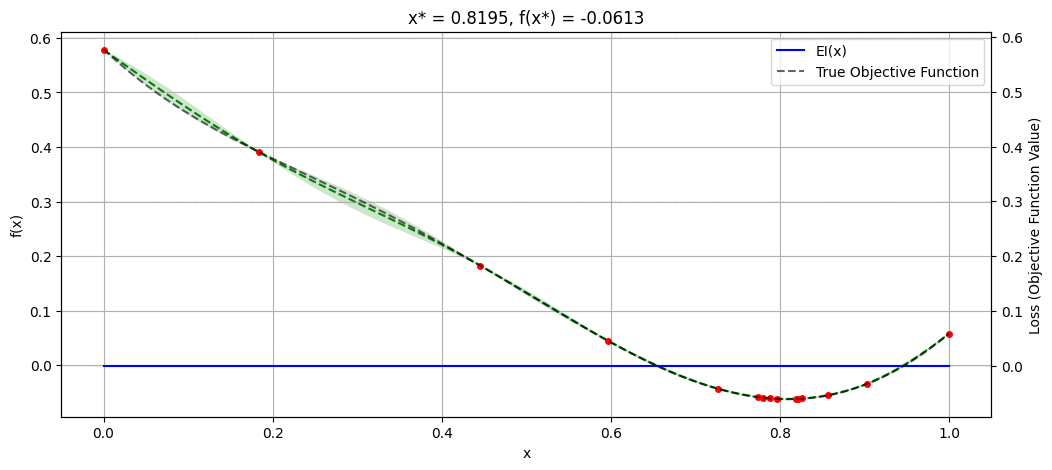

In [5]:
# Find the best result
best_x = results.x[0]
best_loss = results.fun

print("--- Bayesian Optimization Results ---")
print(f"Optimal Hyperparameter (x): {best_x:.4f}")
print(f"Minimum Loss Found: {best_loss:.4f}")

# Plotting the process
plt.figure(figsize=(12, 5))
# This plot shows the Gaussian Process model (surrogate) and how the search proceeded.
plot_gaussian_process(results, show_acq_func=True)

# Add true function plot for comparison
x_range = np.linspace(0.0, 1.0, 100)
y_true = [objective_function([x]) for x in x_range]
plt.plot(x_range, y_true, label='True Objective Function', linestyle='--', color='black', alpha=0.6)

#plt.title('Bayesian Optimization (GP-based) Process')
plt.xlabel('Hyperparameter $x$')
plt.ylabel('Loss (Objective Function Value)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()